In [1]:
import pandas as pd
dataset = pd.read_csv("Placement.csv")
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


### # Q1 - Replace NaN values

In [2]:
dataset["salary"] = dataset["salary"].fillna(0)

print(dataset.isnull().sum())

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64


Explanation:
#
The salary column contains missing values.
#
Missing salary indicates the student was not placed.
#
We replace NaN with 0 to show no salary package received.

### Q2 - How many are not placed?

In [3]:
not_placed_count = (dataset["status"]=="Not Placed").sum()

print("Students not placed:",not_placed_count)

Students not placed: 67


Explanation:
#
The status column contains placement information, and we count the records where status is "Not Placed".
#
The result gives the total number of students not placed.

### Q3 - Find reason for non-placement

In [4]:
from scipy import stats

placed = dataset[dataset["status"]=="Placed"]["ssc_p"]
not_placed = dataset[dataset["status"]=="Not Placed"]["ssc_p"]

stats.f_oneway(placed,not_placed)

F_onewayResult(statistic=np.float64(124.84250634372715), pvalue=np.float64(4.115201043884882e-23))

Explanation:
#
Comparing SSC marks of placed and non-placed students.
#
Significant difference suggests SSC marks influence placement.

### Q4- Relation between salary and mba_p

In [5]:
correlation = dataset["salary"].corr(dataset["mba_p"])

print("Correlation:",correlation)

Correlation: 0.1398227389261557


Explanation:
#
Correlation measures the strength of relationship between two variables.
#
Salary is compared with MBA percentage.
#
Positive value indicates direct relationship and negative value indicates inverse relationship.

### Q5- Which specialization is getting minimum salary?

In [6]:
avg_salary = dataset.groupby("specialisation")["salary"].mean()

print(avg_salary)

print("Minimum Salary Specialization:",avg_salary.idxmin())

specialisation
Mkt&Fin    236591.666667
Mkt&HR     150842.105263
Name: salary, dtype: float64
Minimum Salary Specialization: Mkt&HR


Calculate average salary for each specialization, Compare the averages.
The specialization with the smallest average salary is identified.

### Q6-How many of them getting above 500000 salary?

In [7]:
high_salary = dataset[dataset["salary"] > 500000]

print("Count:",len(high_salary))

Count: 3


Filter students whose salary exceeds ₹500000, Count the number of such records.

### Q7- Test the Analysis of Variance between etest_p and mba_p at signifance level 5%.(Make decision using Hypothesis Testing)

In [8]:
# ANOVA
import scipy.stats as stats

stats.f_oneway(dataset["etest_p"], dataset["mba_p"])

F_onewayResult(statistic=np.float64(98.64487057324708), pvalue=np.float64(4.672547689133573e-21))

Hypothesis
#
H0 : No significant difference between etest_p and mba_p
#
H1 : Significant difference exists between etest_p and mba_p

### Q8- Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary at significance level of 5%.(Make decision using Hypothesis Testing)

In [9]:
# Independent T Test

from scipy.stats import ttest_ind

group1 = dataset[dataset["degree_t"]=="Sci&Tech"]["salary"]
group2 = dataset[dataset["specialisation"]=="Mkt&HR"]["salary"]

ttest_ind(group1,group2,equal_var=False)

TtestResult(statistic=np.float64(2.584058295797713), pvalue=np.float64(0.011110477852831745), df=np.float64(107.15350335695727))

Hypothesis
#
H0 : Both groups have similar salary distribution
#
H1 : Both groups have different salary distribution

### Q9- Convert the normal distribution to standard normal distribution for salary column

In [10]:
# Z Score

salary = dataset[dataset["salary"]!=0]["salary"]

mean = salary.mean()
std = salary.std()

dataset["salary_zscore"] = (dataset["salary"]-mean)/std

dataset[["salary","salary_zscore"]]

,salary,salary_zscore
0,270000.0,-0.199614
1,200000.0,-0.948618
2,250000.0,-0.413615
3,0.0,-3.088629
4,425000.0,1.458895
...,...,...
210,400000.0,1.191393
211,275000.0,-0.146114
212,295000.0,0.067888
213,204000.0,-0.905818


Explanation:
#
Standardization converts data into Z-scores.
#
Mean becomes 0, Standard deviation becomes 1 and so it helps compare values on a common scale.
#
Z = (X - Mean) / Standard Deviation

### Q10- What is the probability Density Function of the salary range from 700000 to 900000?

In [11]:
from scipy.stats import norm

salary = dataset[dataset["salary"]!=0]["salary"]

mean = salary.mean()
std = salary.std()

probability = norm.cdf(900000,mean,std) - norm.cdf(700000,mean,std)

print("Probability:",probability)

Probability: 5.377445759013888e-06


Explaination:
#
Normal distribution is used and probability is calculated for salaries lying between ₹700000 and ₹900000.
#
The result represents the likelihood of a salary falling within that range.

### Q11- Test the similarity between the degree_t(Sci&Tech)with respect toetest_p and mba_p at significance level of 5%.(Make decision using Hypothesis Testing)

In [12]:
# Q11 - Independent T Test

from scipy.stats import ttest_ind

sci = dataset[dataset["degree_t"]=="Sci&Tech"]

ttest_ind(sci["etest_p"], sci["mba_p"])

TtestResult(statistic=np.float64(4.532000225151251), pvalue=np.float64(1.4289217003775636e-05), df=np.float64(116.0))

Hypothesis:
#
H0 : No significant difference between etest_p and mba_p
#
H1 : Significant difference exists


##
T-Test determines whether both variables are significantly different.
#
Students belonging to Sci&Tech are selected and their employability test percentage and MBA percentage are compared.


### Q12- Which parameter is highly correlated with salary?

In [13]:
numeric_data = dataset.select_dtypes(include=["float64","int64"])

corr = numeric_data.corr()

print(corr["salary"].sort_values(ascending=False))

salary           1.000000
salary_zscore    1.000000
ssc_p            0.538090
hsc_p            0.452569
degree_p         0.408371
etest_p          0.186988
mba_p            0.139823
sl_no            0.002543
Name: salary, dtype: float64


Explanation:
#
Correlation matrix is generated and its values with salary are observed.
#
The variable having the highest correlation (has the strongest relationship) with salary is selected.

### Q13- plot any useful graph and explain it.

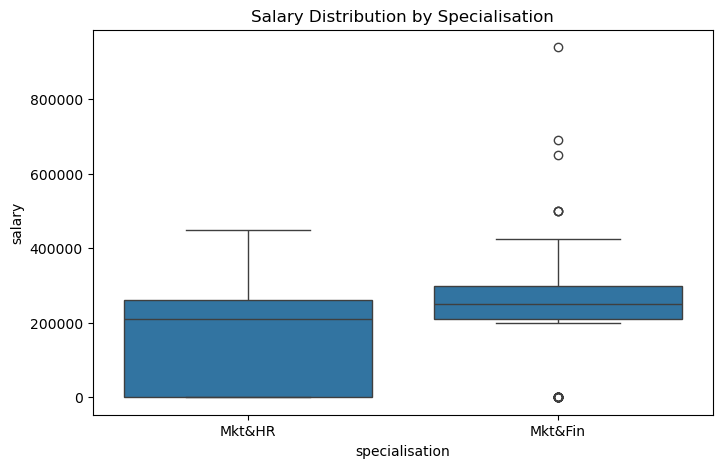

In [14]:
# Box Plot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x="specialisation",
            y="salary",
            data=dataset)

plt.title("Salary Distribution by Specialisation")

plt.show()

plot description:
1. X-axis shows specialization and Y-axis shows salary.
2. Boxplot displays median, quartiles and outliers and it helps to  compare salary distribution among specializations.